# XOR Neural Network Visualization

This notebook demonstrates training a neural network on the XOR problem and visualizing the decision boundary.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from ml_core.losses import BinaryCrossentropy as BCE_Loss
from ml_core import Network as Neural_Network
from ml_core.layers import DenseLayer as Dense_Layer
from ml_core.activations import Sigmoid as Sigmoid_Activation

## XOR Dataset

The XOR (exclusive OR) problem is a classic non-linear classification problem that cannot be solved by a single-layer perceptron.

In [2]:
# Define XOR inputs and expected outputs
inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
labels = [
    [0],
    [1],
    [1],
    [0]
]

# Convert labels to numpy array for calculations
labels = np.array(labels)

## Visualization Function

This function will help us visualize the decision boundary of our neural network model.

In [3]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Visualize decision boundary of a trained model.
    
    Parameters:
        model: instance of your NeuralNetwork class with .forward(x) method
        X: input points (shape: [num_samples, 2])
        y: true binary labels (shape: [num_samples, 1])
    """
    # Convert inputs to numpy arrays if they aren't already
    X = np.array(X)
    y = np.array(y)
    
    h = 0.01  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]  # Shape: [num_points, 2]

    # Predict over grid
    Z = model.forward(grid)
    Z = Z.reshape(xx.shape)  # Reshape to match mesh

    # Plot contour map (decision surface)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, levels=100, cmap="RdBu", alpha=0.6)

    # Overlay true points
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="bwr", edgecolors='k', s=150)
    plt.title(title, fontsize=16)
    plt.xlabel("x₁", fontsize=14)
    plt.ylabel("x₂", fontsize=14)
    plt.grid(True)
    plt.colorbar(label='Prediction')
    plt.show()

## Training the Neural Network

We'll create a neural network with:
- 2 input neurons (for the 2 XOR inputs)
- 4 neurons in the hidden layer
- 1 output neuron (for binary classification)

In [4]:
# Training parameters
num_epochs = 10000
learning_rate = 0.1

# Initialize the loss function
bce_loss = BCE_Loss()

# Initialize the network
# 2 inputs, 4 hidden, 1 output
neural_network = Neural_Network([
    Dense_Layer(input_size=2, output_size=4),
    Sigmoid_Activation(),
    Dense_Layer(input_size=4, output_size=1),
    Sigmoid_Activation(),
])

# Lists to track progress
loss_history = []

In [5]:
# Training loop with progress tracking
for epoch in range(num_epochs):
    # Forward pass
    predictions = neural_network.forward(inputs=inputs)
    loss = bce_loss.forward(predictions=predictions, labels=labels)
    gradient = bce_loss.backward()
    
    # Backward pass
    neural_network.backward(loss_gradient=gradient, learning_rate=learning_rate)
    
    # Record loss every 500 epochs
    if epoch % 500 == 0 or epoch == num_epochs - 1:
        loss_history.append(loss)
        if epoch % 2000 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Loss: {loss:.6f}")

Epoch 0/10000, Loss: 1.197356
Epoch 2000/10000, Loss: 0.679738
Epoch 4000/10000, Loss: 0.624730
Epoch 6000/10000, Loss: 0.498338
Epoch 8000/10000, Loss: 0.330413


## Visualizing Training Progress

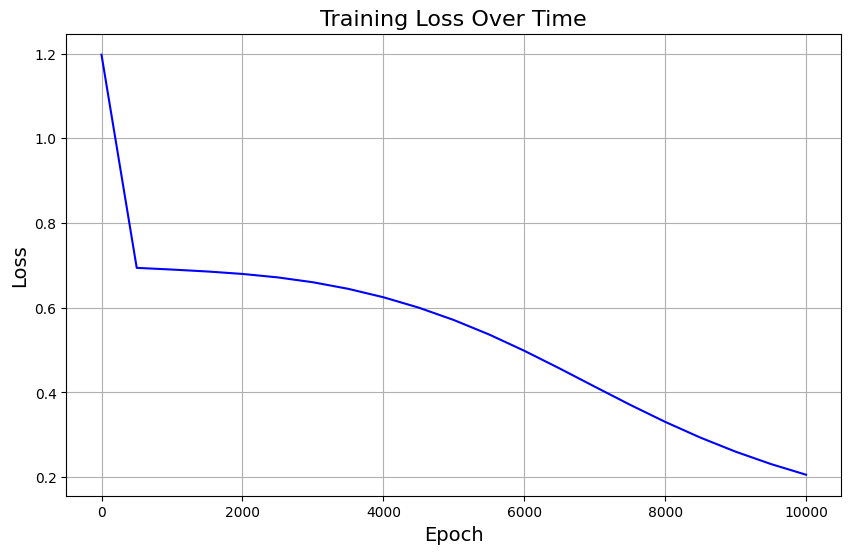

In [6]:
# Plot loss over time
plt.figure(figsize=(10, 6))
epochs_tracked = [i*500 for i in range(len(loss_history)-1)] + [num_epochs-1]
plt.plot(epochs_tracked, loss_history, 'b-')
plt.title('Training Loss Over Time', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.show()

## Evaluating the Model

In [7]:
# Make predictions
final_predictions = neural_network.forward(inputs)
rounded_predictions = np.round(final_predictions)

# Display predictions vs actual
for i in range(len(inputs)):
    print(f"Input: {inputs[i]} | Actual: {labels[i][0]} | Predicted: {final_predictions[i][0]:.4f} | Rounded: {rounded_predictions[i][0]}")

Input: [0, 0] | Actual: 0 | Predicted: 0.1392 | Rounded: 0.0
Input: [0, 1] | Actual: 1 | Predicted: 0.7793 | Rounded: 1.0
Input: [1, 0] | Actual: 1 | Predicted: 0.8645 | Rounded: 1.0
Input: [1, 1] | Actual: 0 | Predicted: 0.2423 | Rounded: 0.0


## Decision Boundary Visualization

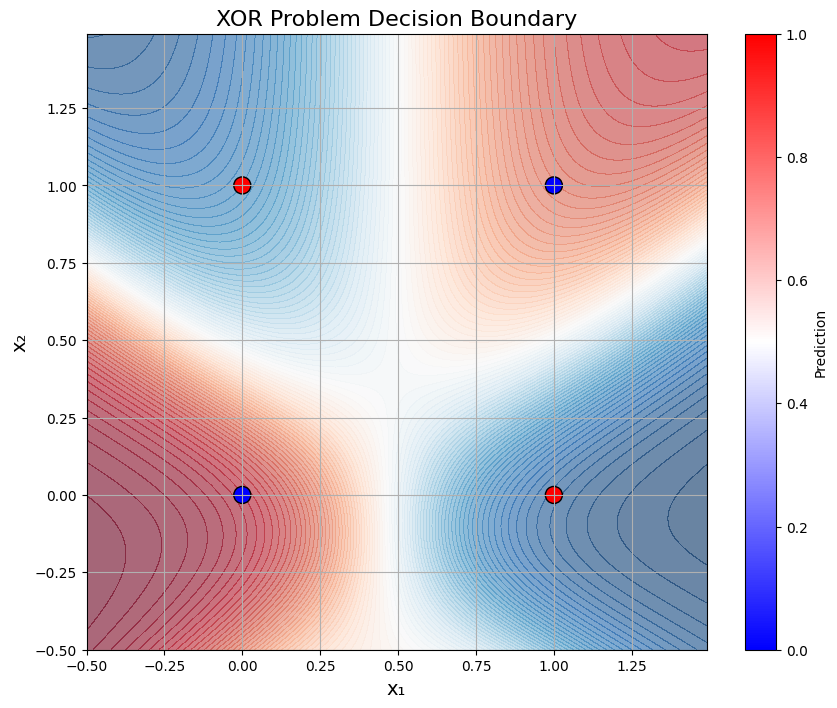

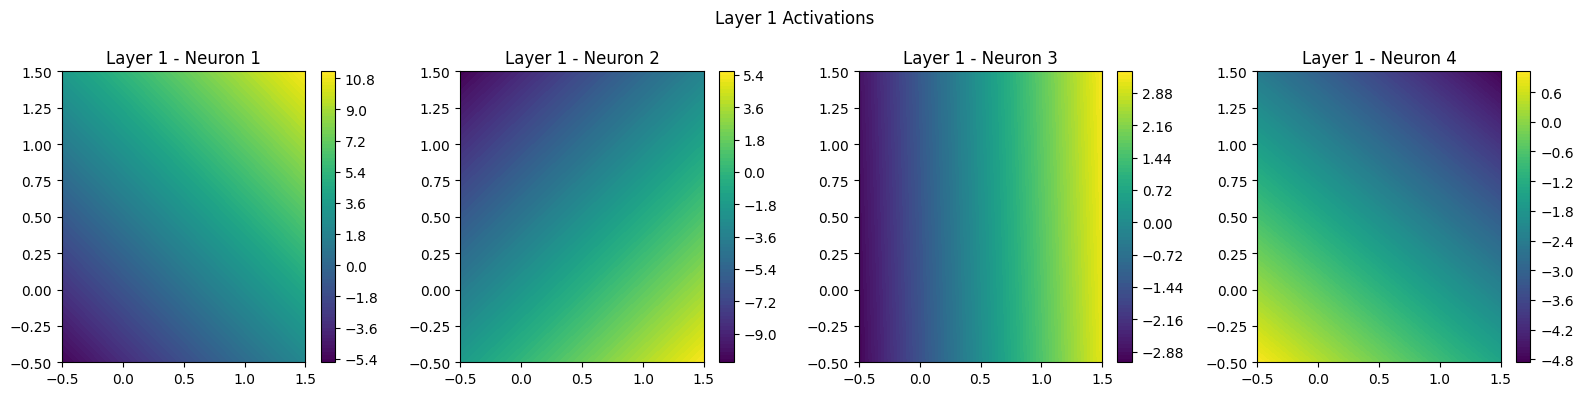

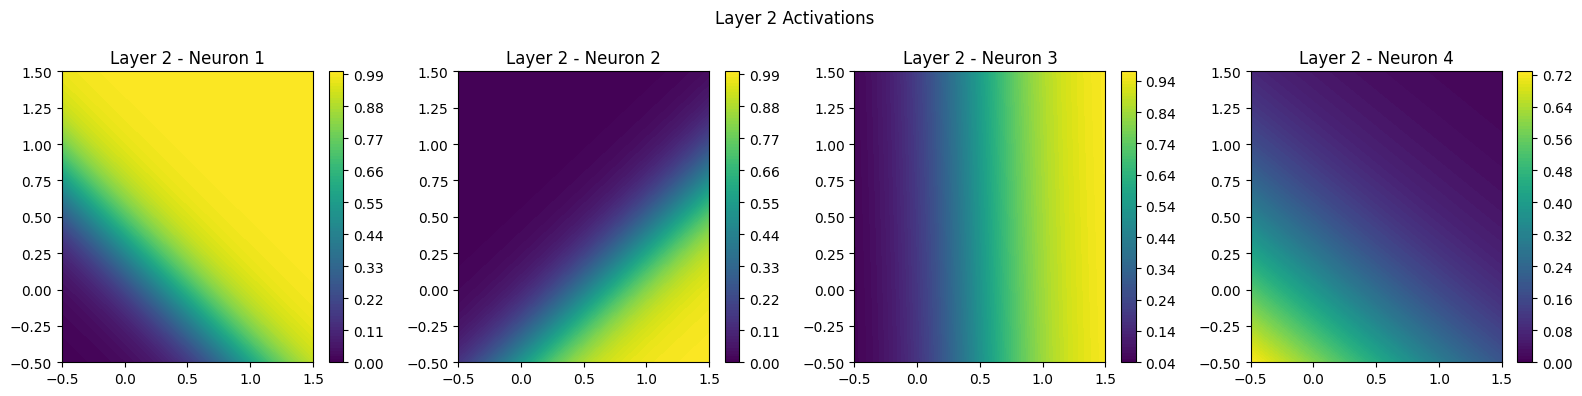

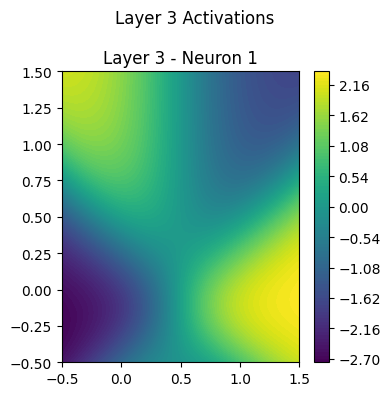

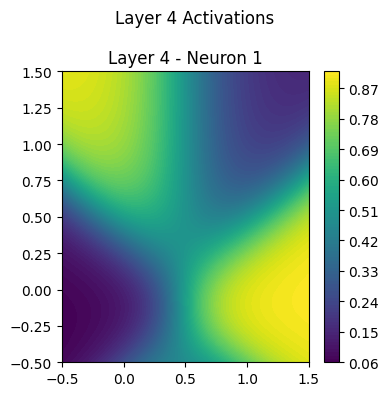

Layer 1 Neuron 1 weights: [ 3.78813857  3.59795629  3.07419034 -1.19899283]
Layer 1 Neuron 2 weights: [ 4.43209831 -4.43019231  0.0959941  -1.70702339]


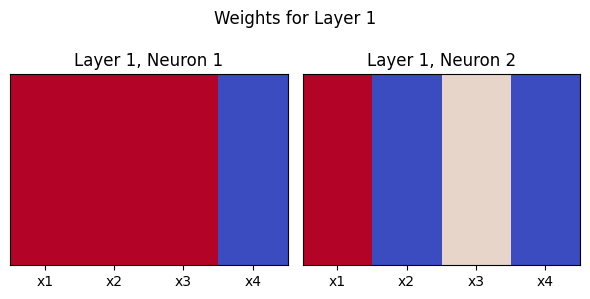

Layer 3 Neuron 1 weights: [4.15337576]
Layer 3 Neuron 2 weights: [4.57260098]
Layer 3 Neuron 3 weights: [-4.53201483]
Layer 3 Neuron 4 weights: [-1.89172641]


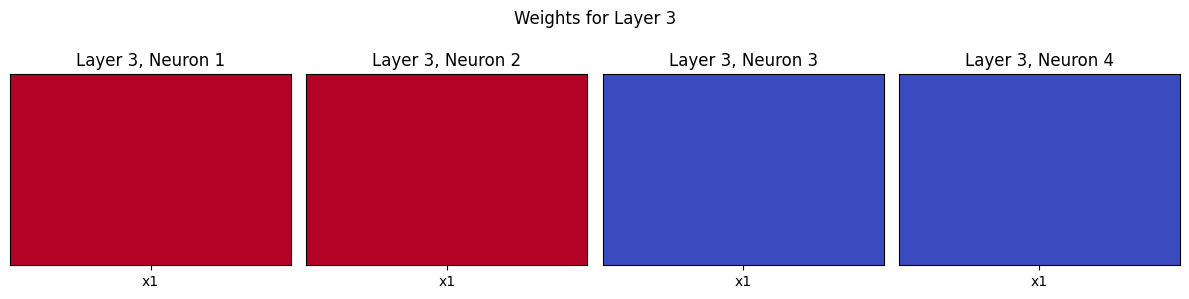

In [8]:
# Visualize the decision boundary
from milestone_1_1.visualize import plot_all_layer_activations
from milestone_1_1.visualize import plot_layer_weights

plot_decision_boundary(model=neural_network, X=inputs, y=labels, title="XOR Problem Decision Boundary")
plot_all_layer_activations(model=neural_network)
plot_layer_weights(neural_network)